# 🌊 Project: The Neural Noise Filter
**Objective:** To visualize how **Regularization (Alpha)** prevents a Neural Network from memorizing random noise and forces it to learn the underlying "Signal".

### 🧪 The Experiment:
1. **Generate Noisy Data:** Create a "Moon" shaped dataset with 30% random noise.
2. **The Overfitter:** Train a deep network with NO regularization (Alpha ≈ 0).
3. **The Generalizer:** Train the same network with High L2 Regularization (Alpha = 0.1).
4. **Visual Proof:** Plot the **Decision Boundaries** to see the difference.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


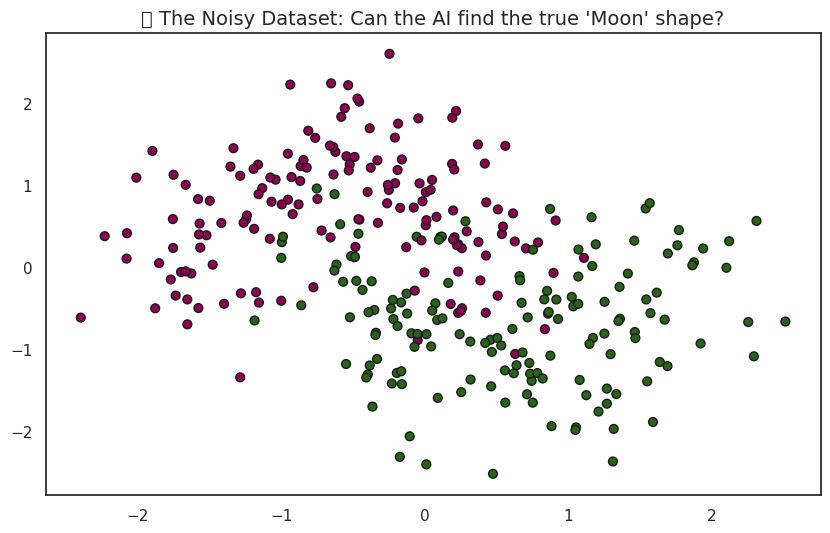

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# Aesthetic Setup
sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = (10, 6)

# ── 1. Create Synthetic "Noisy Moon" Data ──────────────────────────────────
# Noise=0.3 makes the boundaries very messy!
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)

# Scaling is mandatory for Neural Nets
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Plotting the raw noisy data
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='PiYG', edgecolors='k', s=40)
plt.title("🧪 The Noisy Dataset: Can the AI find the true 'Moon' shape?", fontsize=14)
plt.show()

### 🛡️ Understanding the "Alpha" Shield
* **Low Alpha (The Overfitter):** It tries to give every single noisy point its own "island". The boundary will be zig-zag and messy.
* **High Alpha (The Filter):** It penalizes large weights, forcing the boundary to be smooth. It ignores the noise and captures the true shape.

/tmp/ipykernel_5335/2420123581.py:28: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5335/2420123581.py:28: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


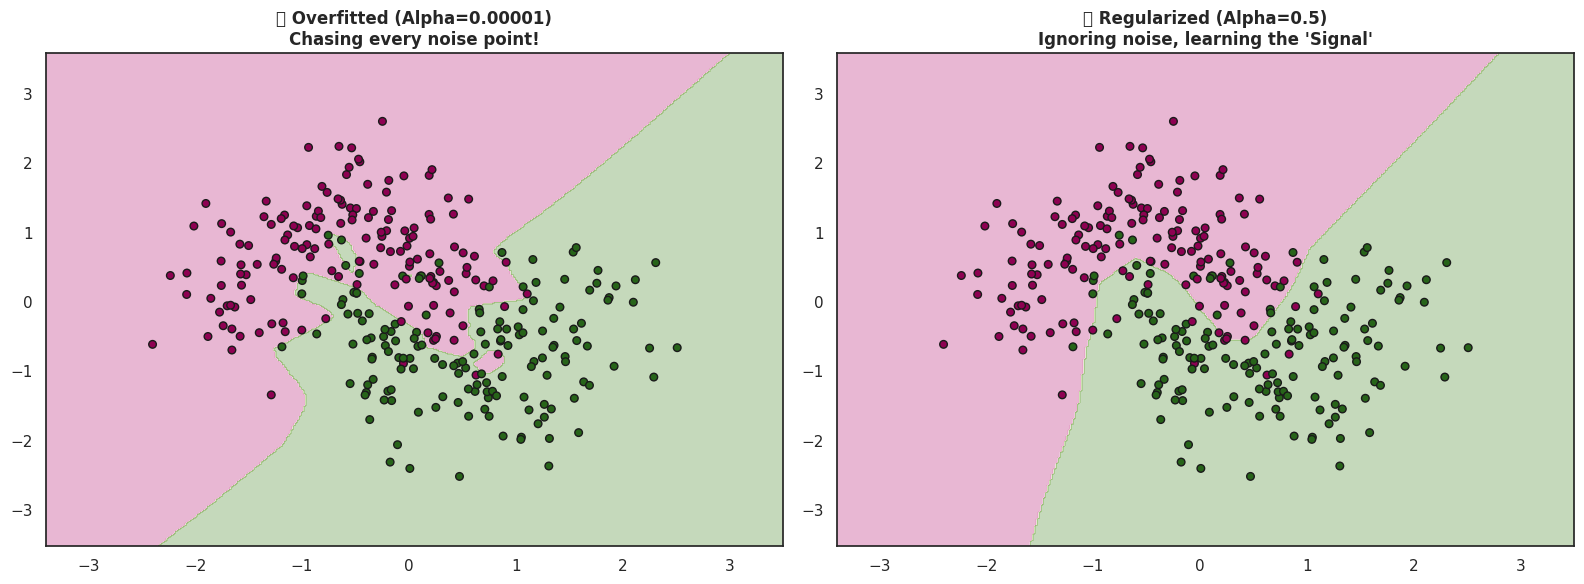

In [3]:
# Function to plot decision boundaries (More Aesthetic)
def plot_boundary(model, X, y, title, ax):
    h = .02  # mesh step size
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap='PiYG', alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='PiYG', edgecolors='k', s=30)
    ax.set_title(title, fontsize=12, fontweight='bold')

# ── 2. Compare Models ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Model 1: Complex & No Regularization (Overfitter)
overfit = MLPClassifier(hidden_layer_sizes=(100, 100, 100), alpha=1e-5, max_iter=1000, random_state=42)
overfit.fit(X_scaled, y)
plot_boundary(overfit, X_scaled, y, "🔴 Overfitted (Alpha=0.00001)\nChasing every noise point!", ax1)

# Model 2: Regularized (The Filter)
smart = MLPClassifier(hidden_layer_sizes=(100, 100, 100), alpha=0.5, max_iter=1000, random_state=42)
smart.fit(X_scaled, y)
plot_boundary(smart, X_scaled, y, "🟢 Regularized (Alpha=0.5)\nIgnoring noise, learning the 'Signal'", ax2)

plt.tight_layout()
plt.show()

## 🩺 Why does this matter in Medical AI?
In the **Breast Cancer** dataset, some measurements might be "outliers" (noise).
* An **Overfitted model** might misdiagnose a patient because it focused too much on a weird data point.
* A **Regularized model** (like the one on the right) stays stable and gives a more reliable diagnosis.

| Feature | Overfitted Model | Regularized Model |
| :--- | :--- | :--- |
| **Complexity** | Extremely High | Managed |
| **Boundary** | Zig-zag / Messy | Smooth / Clean |
| **Test Accuracy** | High on Train, Low on Test | Balanced (Generalised) |
| **Reliability** | Low (Risky) | High (Safe) |

**Conclusion:** For Day 2, we learned that "More Training" isn't always better. **Smart Training** with L2 Regularization is the key! 🚀